In [4]:
#라이브러리 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [5]:
#데이터 불러오기
all_df = pd.read_excel("league.xlsx", sheet_name="all")

In [6]:
#데이터 구조 확인
print(all_df.shape)
all_df.head

(4070, 114)


<bound method NDFrame.head of       Unnamed: 0                                 link_match  \
0              0   https://www.premierleague.com/match/7186   
1              1   https://www.premierleague.com/match/7404   
2              2   https://www.premierleague.com/match/7255   
3              3   https://www.premierleague.com/match/7126   
4              4   https://www.premierleague.com/match/7350   
...          ...                                        ...   
4065        4065  https://www.premierleague.com/match/59113   
4066        4066  https://www.premierleague.com/match/59177   
4067        4067  https://www.premierleague.com/match/59178   
4068        4068  https://www.premierleague.com/match/59182   
4069        4069  https://www.premierleague.com/match/59052   

                   season       date          home_team  \
0     2022-10-11 00:00:00 2010-11-01          Blackpool   
1     2022-10-11 00:00:00 2011-04-11          Liverpool   
2     2022-10-11 00:00:00 2010-12-13

In [7]:
all_df[
    [
        "goal_home_ft",
        "goal_away_ft",
        "home_shots",
        "away_shots",
        "home_shots_on_target",
        "away_shots_on_target",
        "home_passes",
        "away_passes"
    ]
].head()
        

,goal_home_ft,goal_away_ft,home_shots,away_shots,home_shots_on_target,away_shots_on_target,home_passes,away_passes
0,2,1,26,14,5,4,550,280
1,3,0,21,12,5,2,527,465
2,1,0,17,11,6,5,430,499
3,2,1,21,11,9,5,277,382
4,0,0,13,25,5,3,333,580


In [8]:
# 경기 결과 (MatchResult) 생성
def get_result(row):
    if row["goal_home_ft"] > row["goal_away_ft"]:
        return "Home Win"
    elif row["goal_home_ft"] < row["goal_away_ft"]:
        return "Away Win"
    else:
        return "Draw"

all_df["MatchResult"] = all_df.apply(get_result, axis=1)

In [9]:
all_df[[
    "home_team",
    "away_team",
    "goal_home_ft",
    "goal_away_ft",
    "MatchResult"
]].head(10)

all_df["MatchResult"].value_counts() #홈팀 승리가 원정팀 승리보다 약 1.5배 많음

MatchResult
Home Win    1835
Away Win    1235
Draw        1000
Name: count, dtype: int64

In [10]:
#무승부 제거
analysis_df = all_df[all_df["MatchResult"]!="Draw"].copy()
analysis_df.shape

(3070, 115)

In [11]:
#승리팀, 패배팀 별 지표 생성 (반복문)
metrics = {
    "Shots": ("home_shots","away_shots"),
    "OnTarget": ("home_shots_on_target", "away_shots_on_target"),
    "Passes": ("home_passes", "away_passes"),
    "Touches": ("home_touches", "away_touches"),
    "Tackles": ("home_tackles", "away_tackles"),
    "Clearances": ("home_clearances", "away_clearances"),
    "Fouls": ("home_fouls_conceded", "away_fouls_conceded")
}

for metric, (home_col, away_col) in metrics.items():
    analysis_df[f"Winner_{metric}"] = analysis_df.apply(
        lambda row: row[home_col]
        if row["MatchResult"] == "Home Win"
        else row[away_col],
        axis=1
    )
    
    analysis_df[f"Loser_{metric}"] = analysis_df.apply(
        lambda row: row[away_col]
        if row["MatchResult"] == "Home Win"
        else row[home_col],
        axis=1
    )

In [12]:
analysis_df[
    [
        "Winner_Shots",
        "Loser_Shots",
        "Winner_OnTarget",
        "Loser_OnTarget",
        "Winner_Passes",
        "Loser_Passes"
    ]
].head()

,Winner_Shots,Loser_Shots,Winner_OnTarget,Loser_OnTarget,Winner_Passes,Loser_Passes
0,26,14,5,4,550,280
1,21,12,5,2,527,465
2,17,11,6,5,430,499
3,21,11,9,5,277,382
5,19,9,4,4,609,313


In [13]:
#승리팀 유효슈팅률
analysis_df["Winner_Accuracy"] = (
    analysis_df["Winner_OnTarget"] / analysis_df["Winner_Shots"]
)

#패배팀 유효슈팅률
analysis_df["Loser_Accuracy"] = (
    analysis_df["Loser_OnTarget"] / analysis_df["Loser_Shots"]
)

In [14]:
analysis_df[
[
"Winner_Shots",
"Winner_OnTarget",
"Winner_Accuracy",
"Loser_Shots",
"Loser_OnTarget",
"Loser_Accuracy"
]
].head()

,Winner_Shots,Winner_OnTarget,Winner_Accuracy,Loser_Shots,Loser_OnTarget,Loser_Accuracy
0,26,5,0.192308,14,4,0.285714
1,21,5,0.238095,12,2,0.166667
2,17,6,0.352941,11,5,0.454545
3,21,9,0.428571,11,5,0.454545
5,19,4,0.210526,9,4,0.444444


In [15]:
from scipy.stats import ttest_rel #Paired t-test(같은 경기내의 승리팀과 패배팀의 차이)

In [16]:
#가설 검정
#H0: 승리팀과 패배팅 간의 평균 슈팅 수는 차이가 없다.
t,p = ttest_rel(
    analysis_df["Winner_Shots"],
    analysis_df["Loser_Shots"]
)

print("t=",t)
print("p=",p)
# P<0.05, 매우 유의

t= 20.964740955049212
p= 2.584888516463233e-91


In [17]:
print("Winner 평균 슈팅 :", analysis_df["Winner_Shots"].mean())
print("Loser 평균 슈팅 :", analysis_df["Loser_Shots"].mean())

Winner 평균 슈팅 : 14.833550488599348
Loser 평균 슈팅 : 11.501954397394137


In [18]:
test_metrics = [
    "Shots",
    "OnTarget",
    "Passes",
    "Touches",
    "Tackles",
    "Clearances",
    "Fouls"
]

In [19]:
results = []

for metric in test_metrics:
    winner = analysis_df[f"Winner_{metric}"]
    loser = analysis_df[f"Loser_{metric}"]
    
    t,p=ttest_rel(winner,loser)

    results.append({
        "Metric":metric,
        "Winner Mean" : winner.mean(),
        "Loser Mean" : loser.mean(),
        "Mean Difference" : winner.mean() - loser.mean(),
        "t-value" : t,
        "p-value" : p,
        "Significant" : "Yes" if p < 0.05 else "No"
    })

results_df=pd.DataFrame(results).round(3)

results_df

,Metric,Winner Mean,Loser Mean,Mean Difference,t-value,p-value,Significant
0,Shots,14.834,11.502,3.332,20.965,0.000,Yes
1,OnTarget,5.729,3.296,2.433,40.049,0.000,Yes
2,Passes,469.017,420.474,48.543,12.306,0.000,Yes
3,Touches,672.280,620.017,52.263,13.055,0.000,Yes
4,Tackles,18.138,18.024,0.115,0.911,0.363,No
5,Clearances,28.383,24.568,3.815,13.053,0.000,Yes
6,Fouls,10.752,11.010,-0.258,-3.071,0.002,Yes


In [20]:
analysis_df[analysis_df["Loser_Accuracy"].isna()][
[
    "Loser_Shots",
    "Loser_OnTarget",
    "Winner_Shots",
    "Winner_OnTarget",
    "MatchResult"
]
]

,Loser_Shots,Loser_OnTarget,Winner_Shots,Winner_OnTarget,MatchResult
693,0,0,19,5,Home Win
3142,0,0,23,7,Away Win


In [21]:
accuracy_df = analysis_df[
    (analysis_df["Winner_Shots"] > 0) &
    (analysis_df["Loser_Shots"] > 0)
]

winner = accuracy_df["Winner_Accuracy"]
loser = accuracy_df["Loser_Accuracy"]

t, p = ttest_rel(winner, loser)

results_df.loc[len(results_df)] = {
    "Metric": "Accuracy",
    "Winner Mean": round(winner.mean(), 3),
    "Loser Mean": round(loser.mean(), 3),
    "Mean Difference": round(winner.mean() - loser.mean(), 3),
    "t-value": round(t, 3),
    "p-value": round(p, 3),
    "Significant": "Yes" if p < 0.05 else "No"
}

In [22]:
results_df = results_df.sort_values(
    by="p-value"
)

results_df

,Metric,Winner Mean,Loser Mean,Mean Difference,t-value,p-value,Significant
0,Shots,14.834,11.502,3.332,20.965,0.000,Yes
1,OnTarget,5.729,3.296,2.433,40.049,0.000,Yes
2,Passes,469.017,420.474,48.543,12.306,0.000,Yes
3,Touches,672.280,620.017,52.263,13.055,0.000,Yes
5,Clearances,28.383,24.568,3.815,13.053,0.000,Yes
7,Accuracy,0.398,0.292,0.106,29.182,0.000,Yes
6,Fouls,10.752,11.010,-0.258,-3.071,0.002,Yes
4,Tackles,18.138,18.024,0.115,0.911,0.363,No


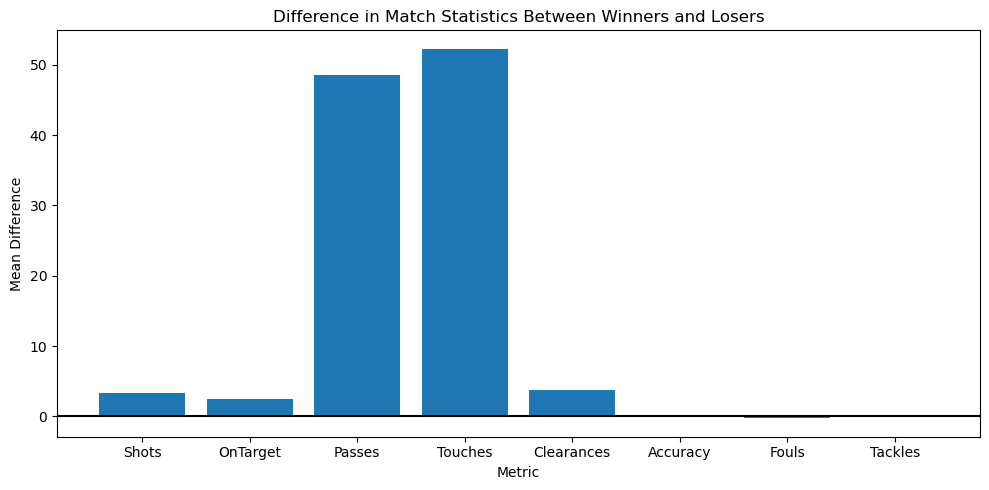

In [23]:
metrics = results_df["Metric"]
winner = results_df["Winner Mean"]
loser = results_df["Loser Mean"]

plt.figure(figsize=(10,5))

plt.bar(results_df["Metric"],
        results_df["Mean Difference"])

plt.axhline(0,color="black")

plt.ylabel("Mean Difference")
plt.xlabel("Metric")
plt.title("Difference in Match Statistics Between Winners and Losers")

plt.tight_layout()
plt.show()

In [24]:
effect_results=[]

for metric in metrics:
    winner=analysis_df[f"Winner_{metric}"]
    loser=analysis_df[f"Loser_{metric}"]

    if metric == "Accuracy":
        temp = pd.DataFrame({
            "winner":winner,
            "loser":loser
        }).dropna()

        winner=temp["winner"]
        loser=temp["loser"]

    diff=winner-loser
    d=diff.mean() / diff.std()

    effect_results.append({
        "Metric":metric,
        "Cohen_d":round(d,3)
    })
effect_df = pd.DataFrame(effect_results).sort_values(
    by="Cohen_d",
    ascending=False
)
effect_df

,Metric,Cohen_d
1,OnTarget,0.723
5,Accuracy,0.527
0,Shots,0.378
3,Touches,0.236
4,Clearances,0.236
2,Passes,0.222
7,Tackles,0.016
6,Fouls,-0.055


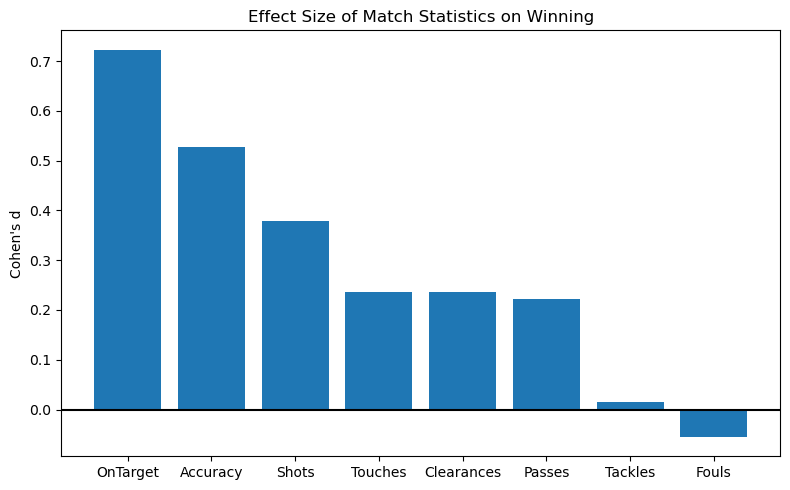

In [25]:
plt.figure(figsize=(8,5))

plt.bar(effect_df["Metric"], effect_df["Cohen_d"])

plt.axhline(0,color="black")

plt.ylabel("Cohen's d")
plt.title("Effect Size of Match Statistics on Winning")

plt.tight_layout()
plt.show()

In [26]:
final_df = results_df.merge(effect_df, on="Metric")

final_df=final_df.sort_values(
    by="Cohen_d",
    ascending=False
)

final_df
#승리팀과 패배팀의 평균이 다른가? 비교 >> 유효슈팅이 가장 차이가 크므로 중요한 지표

,Metric,Winner Mean,Loser Mean,Mean Difference,t-value,p-value,Significant,Cohen_d
1,OnTarget,5.729,3.296,2.433,40.049,0.000,Yes,0.723
5,Accuracy,0.398,0.292,0.106,29.182,0.000,Yes,0.527
0,Shots,14.834,11.502,3.332,20.965,0.000,Yes,0.378
3,Touches,672.280,620.017,52.263,13.055,0.000,Yes,0.236
4,Clearances,28.383,24.568,3.815,13.053,0.000,Yes,0.236
2,Passes,469.017,420.474,48.543,12.306,0.000,Yes,0.222
7,Tackles,18.138,18.024,0.115,0.911,0.363,No,0.016
6,Fouls,10.752,11.010,-0.258,-3.071,0.002,Yes,-0.055


In [ ]:
#연구질문: 승리와 가장 강한 연관성을 보이는 핵심 경기 지표는 무엇인가?
# 1.기술통계: 승리팀과 패비 팀의 주요 경기지표를 비교
# 2. 가설검정: 승리팀과 패배팀의 경기지표 평균에는 차이가 없다(귀무)
# 3. 대응표본 t-test: 각 경기에서 승리팀과 패배팀의 평균 차이를 검정
# 4. 문제점: 평균 차이만으로는 단위가 달라 직접 비교가 어려움
# 5. 해결: 효과크기(Cohen's d)를 계산하여 OnTarget이 가장 효과크기가 큼을 확인
##결론: 승리팀과 패배팀의 경기지표를 확인한 결과, 대부분의 변수에서 유의미한 차이 존재.
## -> 유효슈팅과 슈팅정확도가 승패를 가장 크게 구분하는 핵심 변수 >> 결정적인 기회를 얼마나 정확하게 마무리하는지가 승리에 더 큰 영향